
=== kNN (KD-Tree, p=1, k=9) ===
Fit (build tree) time:     0.8688 s
Predict time:              37.7269 s
Predict_proba time:        37.4574 s
Accuracy:                  0.7262
ROC-AUC:                   0.7908

Classification Report:
              precision    recall  f1-score   support

           0      0.745     0.689     0.716      7070
           1      0.710     0.764     0.736      7069

    accuracy                          0.726     14139
   macro avg      0.728     0.726     0.726     14139
weighted avg      0.728     0.726     0.726     14139



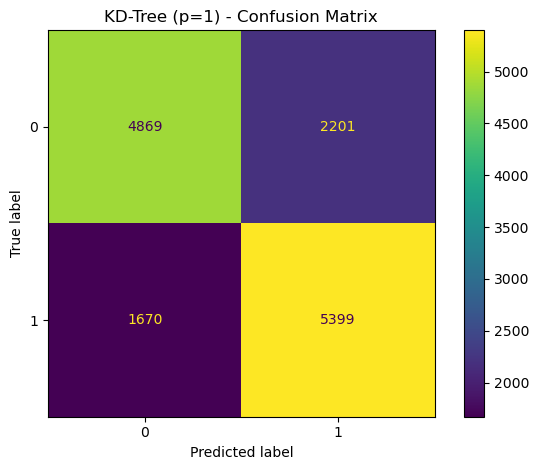


Saved: kd_tree_summary_p1_k9.csv and kd_tree_predictions_p1_k9.csv


In [2]:

# kNN with KD-Tree — timed (single run, no comparisons)


import time
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score
)

# ---- Load preprocessed data 
X_train = pd.read_csv("X_train_scaled.csv")
X_test  = pd.read_csv("X_test_scaled.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
y_test  = pd.read_csv("y_test.csv").squeeze()

# ---- Config (KD-tree + Euclidean). Set p=1 for Manhattan 
K = 9
P = 1                 # 2 = Euclidean, 1 = Manhattan
ALGO = "kd_tree"      # force KD-Tree

# ---- Train (fit) — time it ----
t0 = time.time()
knn_kd = KNeighborsClassifier(
    n_neighbors=K,
    algorithm=ALGO,
    metric="minkowski",
    p=P,
    weights="uniform"
)
knn_kd.fit(X_train, y_train)
fit_time = time.time() - t0

# ---- Predict — time it ----
t1 = time.time()
y_pred  = knn_kd.predict(X_test)
pred_time = time.time() - t1

# (Optional) Predict probabilities — time it separately
t2 = time.time()
y_proba = knn_kd.predict_proba(X_test)[:, 1]
proba_time = time.time() - t2

# ---- Metrics ----
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
report = classification_report(y_test, y_pred, digits=3)
cm = confusion_matrix(y_test, y_pred)

print(f"\n=== kNN (KD-Tree, p={P}, k={K}) ===")
print(f"Fit (build tree) time:     {fit_time:.4f} s")
print(f"Predict time:              {pred_time:.4f} s")
print(f"Predict_proba time:        {proba_time:.4f} s")
print(f"Accuracy:                  {acc:.4f}")
print(f"ROC-AUC:                   {auc:.4f}\n")
print("Classification Report:")
print(report)

# ---- Confusion Matrix ----
ConfusionMatrixDisplay(confusion_matrix=cm).plot(values_format="d")
plt.title(f"KD-Tree (p={P}) - Confusion Matrix")
plt.tight_layout()
plt.show()

# ---- Save artifacts (optional) ----
summary = pd.DataFrame({
    "k":[K], "p":[P], "algorithm":[ALGO],
    "fit_time_s":[fit_time],
    "predict_time_s":[pred_time],
    "predict_proba_time_s":[proba_time],
    "accuracy":[acc], "roc_auc":[auc]
})
summary.to_csv(f"kd_tree_summary_p{P}_k{K}.csv", index=False)

pred_df = pd.DataFrame({"Actual": y_test, "Predicted": y_pred, "Probability": y_proba})
pred_df.to_csv(f"kd_tree_predictions_p{P}_k{K}.csv", index=False)

print(f"\nSaved: kd_tree_summary_p{P}_k{K}.csv and kd_tree_predictions_p{P}_k{K}.csv")
